# Лабораторная работа 2: «Разработка сверточной нейронной сети с использованием PyTorch»

Выполнил студент группы 3824М1ПМвм Шокуров Даниил

Цель работы — разработать и обучить сверточную нейронную сеть для задачи классификации изображений на наборе данных CIFAR-10 с использованием фреймворка PyTorch.


## Задачи работы

Выполнение лабораторной работы предполагает решение следующих задач:

1. Загрузить набор данных CIFAR-10 и выполнить предобработку данных, если это необходимо.
2. Реализовать сверточную нейронную сеть с использованием фреймворка PyTorch.
3. Выбрать подходящую функцию потерь и настроить гиперпараметры обучения.
4. Обучить реализованную нейронную сеть и провести оценку качества её работы.

In [ ]:
# Импортируем необходимые библиотеки
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import time
import os
import numpy as np

In [ ]:
PATH = "best_model_cifar10.pth"

In [ ]:
# Выбор девайса
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Зададим гиперпараметры
batch_size = 128
learning_rate = 0.1
epochs = 50

In [ ]:
# Аугментируем данные для лучшей обучаемости
transform_train = transforms.Compose([
transforms.RandomCrop(32, padding=4),             # Случайный кроп с padding
    transforms.RandomHorizontalFlip(p=0.5),       # Случайное горизонтальное отражение
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,             # Изменение яркости и контраста
        saturation=0.2, hue=0.1                   # Изменение насыщенности и оттенка
    ),
    transforms.RandomRotation(degrees=15),        # Случайный поворот
    transforms.ToTensor(),
])

In [ ]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

In [ ]:
# Применение трансформации для изображнений
def transform_images(transform, images): # (n, 32, 32, 3)
  N, H, W, C = images.shape
  augmented_data = torch.empty(N, C, H, W)
  for i in range(0, len(images)):
    img = transforms.ToPILImage()(images[i])
    augmented_data[i] = transform(img)
  return augmented_data

In [ ]:
def show_images(up_images, down_images):
  h, w = 2, 6

  N = len(up_images)
  indexes = [np.random.randint(0, N) for _ in range(w)]

  # До преобразований
  imgs = up_images
  plt.figure(figsize=(w * 2, h * 2))
  for i in range(w):
    plt.subplot(h, w, i + 1)
    plt.imshow(transforms.ToPILImage()(imgs[indexes[i]]))
    plt.axis('off')

  # После преобразований
  imgs = down_images
  for i in range(w):
    plt.subplot(h, w, (i + 1) + w)
    plt.imshow(transforms.ToPILImage()(imgs[indexes[i]]))
    plt.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
# Тренировочные данные после аугментации
augmented_data = transform_images(transform_train, train_dataset.data)

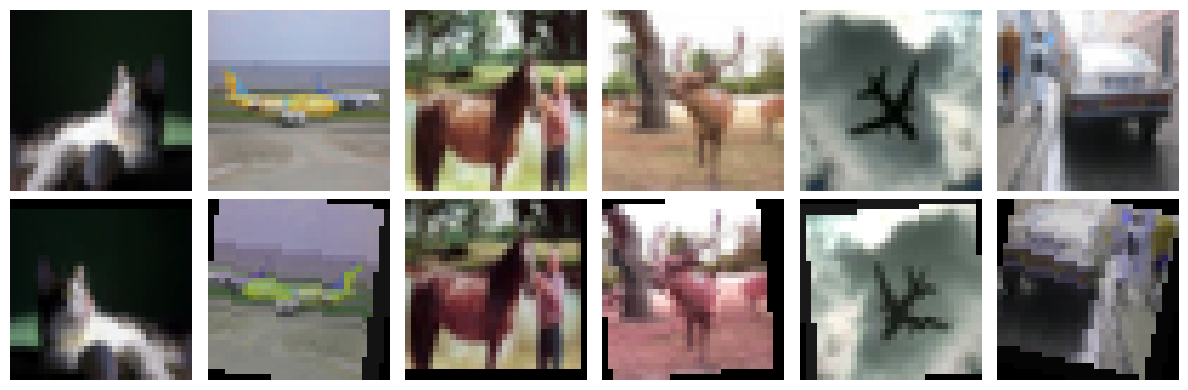

In [ ]:
# Сравнение изображений
show_images( train_dataset.data, augmented_data.data)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [ ]:
# Загружаем модель
model = ResNet18().to(device)

In [ ]:
# Загружаем веса лучшей модели если есть
if os.path.exists(PATH):
  model.load_state_dict(torch.load(PATH, weights_only=True))

In [ ]:
# Задаем критерий и алгоритм оптимизации
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train(epoch):
    model.train()
    common_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        common_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_acc = 100. * correct / total
    print(f'Epoch: {epoch} | Train Loss: {common_loss/(batch_idx+1):.3f} | Train Acc: {train_acc:.3f}%')
    return train_acc

In [ ]:
def test(epoch):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_acc = 100. * correct / total
    print(f'Epoch: {epoch} | Test Loss: {test_loss/(batch_idx+1):.3f} | Test Acc: {test_acc:.3f}%')
    return test_acc

In [ ]:
train_accuracies = []
test_accuracies = []

start_time = time.time()

# Основной тренировочный цикл
for epoch in range(1, epochs + 1):
    train_acc = train(epoch)
    test_acc = test(epoch)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if test_acc >= max(test_accuracies):
        torch.save(model.state_dict(), PATH)

end_time = time.time()
print(f"Время обучения {(end_time - start_time)/60:.2f} минут")

Epoch: 1 | Train Loss: 1.947 | Train Acc: 25.638%
Epoch: 1 | Test Loss: 2.356 | Test Acc: 18.670%
Epoch: 2 | Train Loss: 1.730 | Train Acc: 35.212%
Epoch: 2 | Test Loss: 1.567 | Test Acc: 42.690%
Epoch: 3 | Train Loss: 1.475 | Train Acc: 45.620%
Epoch: 3 | Test Loss: 1.452 | Test Acc: 49.530%
Epoch: 4 | Train Loss: 1.331 | Train Acc: 51.522%
Epoch: 4 | Test Loss: 1.270 | Test Acc: 54.160%
Epoch: 5 | Train Loss: 1.209 | Train Acc: 56.536%
Epoch: 5 | Test Loss: 1.267 | Test Acc: 56.350%
Epoch: 6 | Train Loss: 1.132 | Train Acc: 59.450%
Epoch: 6 | Test Loss: 1.075 | Test Acc: 61.270%
Epoch: 7 | Train Loss: 1.041 | Train Acc: 62.842%
Epoch: 7 | Test Loss: 1.003 | Test Acc: 65.820%
Epoch: 8 | Train Loss: 0.964 | Train Acc: 65.884%
Epoch: 8 | Test Loss: 0.938 | Test Acc: 67.690%
Epoch: 9 | Train Loss: 0.903 | Train Acc: 68.290%
Epoch: 9 | Test Loss: 0.984 | Test Acc: 67.550%
Epoch: 10 | Train Loss: 0.857 | Train Acc: 70.090%
Epoch: 10 | Test Loss: 0.797 | Test Acc: 72.320%
Epoch: 11 | Train 

Text(0.5, 1.0, 'Графики точности')

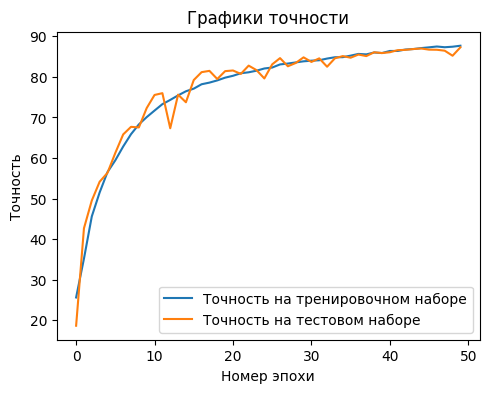

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Точность на тренировочном наборе')
plt.plot(test_accuracies, label='Точность на тестовом наборе')
plt.xlabel('Номер эпохи')
plt.ylabel('Точность')
plt.legend()
plt.title('Графики точности')

In [ ]:
model.load_state_dict(torch.load(PATH))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

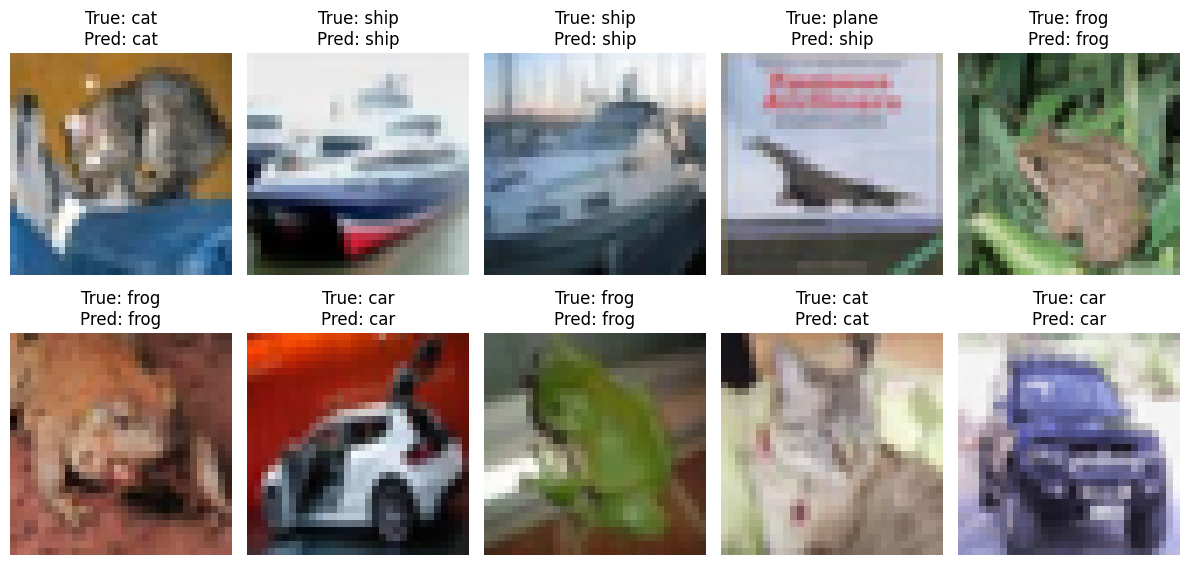

Лучшая точность на тестовой выборке: 87.29%


In [ ]:
# Предскажем результат на тестовой выборке
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Покажем некоторые результаты
images = images.cpu()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.set_title(f'True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Лучшая точность на тестовой выборке: {max(test_accuracies):.2f}%")